# Gradient Descent for Traffic Forecasting

In this notebook, we will attempt to use machine learning optimisation algorithms to predict latency (response time) from request rates.

First, we compare the results of gradient descent and the normal equation. We then create two linear models:
1. **Model 1**: Predict **CPU** from time — forecast CPU in the near future. This model has **one feature**, CPU.
2. **Model 2**: Predict **latency** from CPU and network (RX/TX) — estimate latency given the forecasted CPU. This model has **three features**, CPU, Network RX, and Network TX.

By using this notebook, we hope to help you develop some reasoning about how machine learning prediction works with multiple features and how optimisation algorithms work to reduce the prediction error (Mean-Squared Error).

We use the Microservices Bottleneck Detection dataset, available on Kaggle ([gagansomashekar/microservices-bottleneck-detection-dataset](https://www.kaggle.com/datasets/gagansomashekar/microservices-bottleneck-detection-dataset)).

---
## Introduction to Gradient Descent in Linear Regression

As we learned in our [previous notebook](https://github.com/OpeOnikute/promml/blob/main/notebooks/linear_predict.ipynb), **Linear regression** fits a linear function to data. The basic fit though, does not account for errors. To make predictions more accurate, optimisation algorithms exist to reduce the errors. 

We can measure the "cost" of each training example - the difference between the actual and predicted values, and minimize the mean squared error (MSE) of all the training examples. Given features $X$ and target $y$:

$$\hat{y} = X\theta \quad \text{, minimize} \quad \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2$$

There are two common algorithms to minimise the MSE.

1. **Closed-form (normal equation)**: $\theta = (X^T X)^{-1} X^T y$ — computes the weights in one step using matrix multiplication. It provides the optimal solution in one go, but **can be slow for large datasets**.
2. **Gradient descent**: we start with $\theta = 0$, then repeatedly update $\theta \leftarrow \theta - \alpha \cdot \frac{2}{n} X^T(X\theta - y)$. $\alpha$ is the **learning rate**, which controls how big a step we take when adjusting the weights. We also run for a fixed number of **epochs**, or until the gradient is tiny, as which point we say it has **converged**.

---
## Playing around with Traffic Forecasting

You may want to know what level of traffic your system can safely handle. Typically, you'd be stuck looking at current graphs and setting alert thresholds, or configuring autoscaling groups to react when CPU starts to burn. But thresholds are static and don't evolve with your system, and customers could see impact if autoscaling happens even slightly late.

We are giving you a two-for-one bonus: learn about gradient descent, and if you can use machine learning to forecast traffic and do capacity planning before your customers notice.

We will come up with two models:

| Model | Features ($X$) | Target ($y$) | Purpose |
|-------|----------------|--------------|--------|
| **Model 1** | Intercept, Time | CPU | Forecast CPU in 30 minutes using a simple linear trend. |
| **Model 2** | Intercept, CPU, net RX, net TX | Latency (ms) | Estimate latency from the forecasted CPU and network. |

Our final solution will combine these models **end-to-end**:

Use Model 1 to forecast CPU 30 minutes ahead, then plug into Model 2 to estimate latency at that time. We can then decide what to do if the estimated latency is greater than our SLO.

---
## The Data: Microservices with Bottlenecks

Our data has been converted from Prometheus metrics to one CSV per example. Each row is a request; with metrics (CPU, memory, network RX/TX). 

A (simplified) example of 5 rows from one such CSV might look like this:

| window_id | service   | cpu_seconds | net_rx_bytes | net_tx_bytes | latency_ms |
|-----------|-----------|-------------|--------------|--------------|-----------:|
| 0_0       | user      | 0.23        | 1_520_000    | 1_310_000    |      112.5 |
| 0_1       | home      | 0.19        | 1_430_000    | 1_280_000    |       96.7 |
| 1_0       | user      | 0.27        | 1_640_000    | 1_420_000    |      118.2 |
| 1_1       | home      | 0.21        | 1_510_000    | 1_350_000    |      101.3 |
| 2_0       | compose   | 0.25        | 1_700_000    | 1_560_000    |      123.9 |

We have chosen some scenarios in the `scenarios/` folder and prefixed with `<c-latency>-`. These are the examples that have CPU and network rising over time, with latency staying low then jumping when the system saturates. This behaviour presents our first observation: **latency becomes non-linear when saturation happens**. 

### Setup: install dependencies

Run the cells below to set up the lab. We first  install packages into whichever Python the notebook kernel is using. The next cell then chooses an example scenario and loads the data in for us.

In [1]:
# Install dependencies into the current Jupyter kernel (run this cell once if you get ModuleNotFoundError).
# If you use a venv, select it as the kernel: Kernel → Change Kernel → Python (./.venv/...)
%pip install numpy pandas matplotlib ipywidgets --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Set up the notebook: choose one example from the dataset
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "linear_regression_saturation.py").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helpers from our scripts
from visualise_processed_dataset import *
from linear_regression_saturation import *

# Resolves paths, picks first <c-latency> scenario, loads aggregated window data and metric columns.
# Pass data_dir=Path("...") to override the processed dataset location.
win, metric_cols, CHOSEN_STEM = setup_notebook()
print(f"Chosen scenario: {CHOSEN_STEM}")
print(f"Windows: {len(win)}")

Chosen scenario: cpu_aug9_25min_400_8_graph_1
Windows: 290


---
## Step 1: Visualise all the data

For our chosen scenario, let's see the trends of the features. Examine the time series of CPU, memory, network RX/TX, and latency per window.

It's likely that the CPU is trending upward linearly, while the latency becomes non-linear once saturation starts to set in.

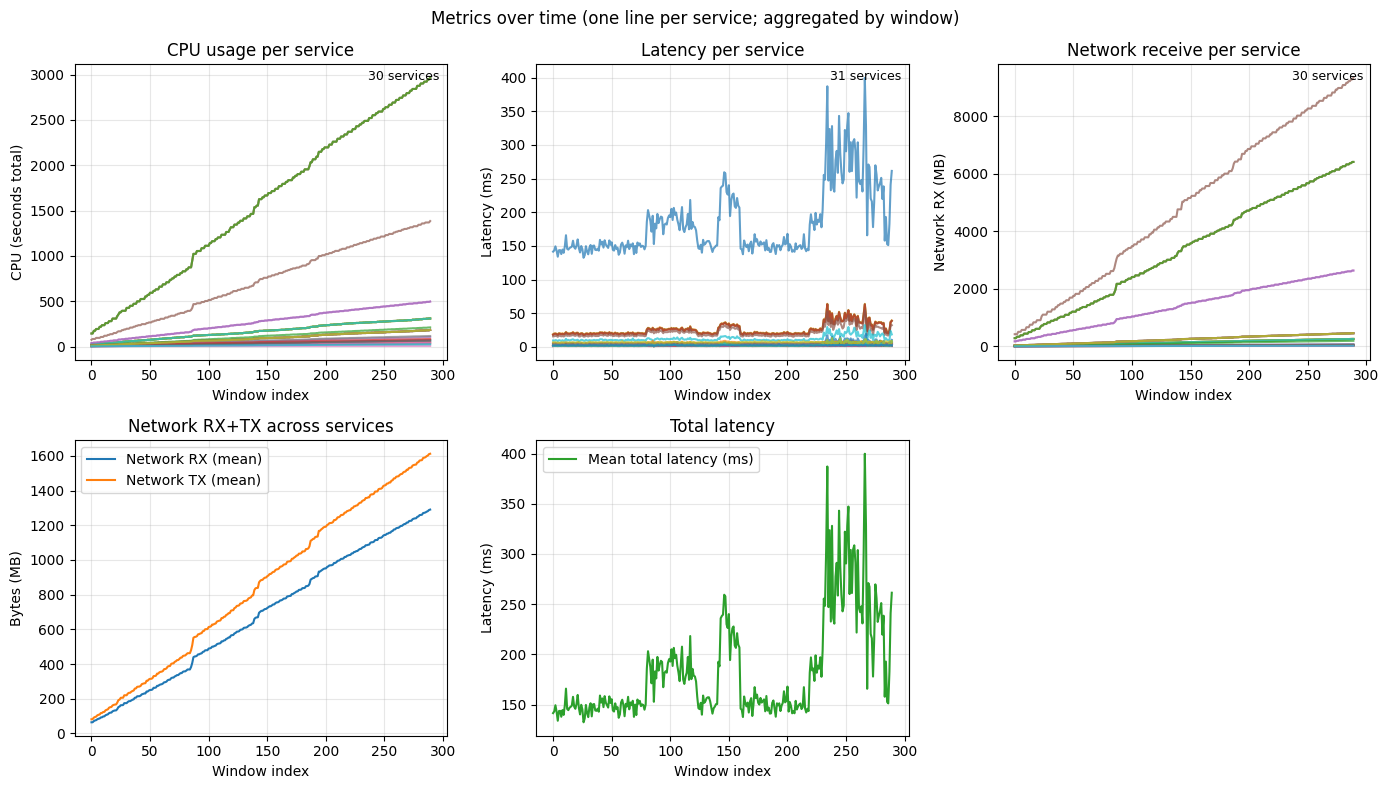

In [3]:
plot_time_series(win, metric_cols, show=True)

---
## Step 2: Implement Model 1 (Predicting CPU from Time with Gradient Descent and Normal Equation)

The first model learns to predict CPU using linear regression. **Features and target:** design matrix $X$ with each row $[1, t_i]$ (intercept and time/window index) and target $y = \text{CPU}$ (mean CPU per window):

$$\hat{y} = X\theta \quad \text{with} \quad X = \begin{bmatrix} 1 & t_1 \\ 1 & t_2 \\ \vdots & \vdots \\ 1 & t_n \end{bmatrix}, \quad y = \begin{bmatrix} \text{CPU}_1 \\ \vdots \\ \text{CPU}_n \end{bmatrix}.$$

**How $\theta$ is produced:** we minimize mean squared error. Two equivalent approaches:

- **Closed-form (normal equation):** $\theta = (X^T X)^{-1} X^T y$ (with a small ridge term for numerical stability).
- **Gradient descent:** initialize $\theta$, then update $\theta \leftarrow \theta - \alpha \cdot \frac{2}{n} X^T(X\theta - y)$ for a learning rate $\alpha$ until convergence.

The code below implements both. Gradient descent needs a suitable learning rate and enough epochs to converge. Run the code blocks to see each solution fit a line to the CPU trend.

In [ ]:
def fit_closed_form(X, y):
    """Normal equation: theta = (X'X)^{-1} X'y. Ridge (lam=1e-6) for stability."""
    lam = 1e-6
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

def fit_gradient_descent(X, y, lr=0.1, epochs=50_000, tol=1e-8):
    """Gradient descent: theta := theta - lr * (2/n) * X'(X theta - y). Stops when gradient norm < tol."""
    n = X.shape[0]
    theta = np.zeros(X.shape[1])
    for _ in range(epochs):
        pred = X @ theta
        grad = (2 / n) * (X.T @ (pred - y))
        if np.linalg.norm(grad) < tol:
            break
        theta -= lr * grad
    return theta

def plot_cpu_model1(t, y_actual, pred_cf, pred_gd, stem):
    """Plot actual CPU vs closed-form and gradient-descent predictions."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, y_actual, "k.", alpha=0.6, label="Actual CPU")
    ax.plot(t, pred_cf, "C0-", alpha=0.9, label="Predicted (closed-form)")
    ax.plot(t, pred_gd, "C1--", alpha=0.9, label="Predicted (gradient descent)")
    ax.set_xlabel("Window index (time)")
    ax.set_ylabel("CPU")
    ax.set_title(f"Model 1: CPU vs time — {stem}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# X = [1, t], y = CPU
cpu_mean = win[metric_cols["cpu"]].mean(axis=1).values
n_windows = len(cpu_mean)
t = np.arange(n_windows, dtype=float)
X_cpu = np.column_stack([np.ones(n_windows), t])
y_cpu = cpu_mean

# Closed-form: theta = (X'X)^{-1} X'y
theta_cf = fit_closed_form(X_cpu, y_cpu)
pred_cf = X_cpu @ theta_cf

# Gradient descent: iterative (scale features for stability)
X_gd = X_cpu.copy()
X_gd[:, 1] = (X_gd[:, 1] - X_gd[:, 1].mean()) / (X_gd[:, 1].std() + 1e-8)
y_gd = (y_cpu - y_cpu.mean()) / (y_cpu.std() + 1e-8)
theta_gd = fit_gradient_descent(X_gd, y_gd, lr=0.5, epochs=5000)
pred_gd = (X_gd @ theta_gd) * y_cpu.std() + y_cpu.mean()

plot_cpu_model1(t, y_cpu, pred_cf, pred_gd, CHOSEN_STEM)

### Step 2.1: Tune the Learning Rate and number of Epochs

Use the sliders below to see how gradient descent fails to converge when the learning rate is too small or epochs too few, and converges when they are adequate.

In [ ]:
from ipywidgets import interact, FloatLogSlider, IntSlider

def run_gd_cpu(lr=0.1, epochs=5000):
    X_gd = X_cpu.copy()
    X_gd[:, 1] = (X_gd[:, 1] - X_gd[:, 1].mean()) / (X_gd[:, 1].std() + 1e-8)
    y_gd = (y_cpu - y_cpu.mean()) / (y_cpu.std() + 1e-8)
    theta = fit_gradient_descent(X_gd, y_gd, lr=lr, epochs=epochs)
    pred = (X_gd @ theta) * y_cpu.std() + y_cpu.mean()
    mse = np.mean((y_cpu - pred) ** 2)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, y_cpu, "k.", alpha=0.6, label="Actual CPU")
    ax.plot(t, pred_cf, "C0-", alpha=0.8, label="Closed-form")
    ax.plot(t, pred, "C1--", alpha=0.9, label=f"GD (lr={lr}, epochs={epochs}), MSE={mse:.4f}")
    ax.set_xlabel("Window index")
    ax.set_ylabel("CPU")
    ax.set_title("Model 1: effect of learning rate and epochs")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    run_gd_cpu,
    lr=FloatLogSlider(value=0.1, base=10, min=-3, max=0, step=0.2, description="Learning rate"),
    epochs=IntSlider(value=5000, min=100, max=50000, step=500, description="Epochs"),
)

: 

---
## Step 3: Implement Model 2 (Predict Latency from CPU and Network)

We want to estimate **how future demand will impact latency**: if load (CPU and network traffic) keeps trending up, what latency can we expect in 30 minutes? We do this in two steps:
1. **Forecast CPU (and optionally net RX/TX)** in 30 minutes using Model 1.
2. **Plug those values into Model 2** (latency from CPU and network) to estimate latency at that time.

Note that Model 2 is only reliable in the **baseline** (pre-saturation) period. Once the system saturates, latency is no longer linear against CPU/network.

**Features and target:** we have multiple features per window: intercept, CPU, network RX (MB), network TX (MB). So each row $i$ is a feature vector and we predict latency (ms):

$$X = \begin{bmatrix} 1 & \text{cpu}_1 & \text{net\_rx}_1 & \text{net\_tx}_1 \\ 1 & \text{cpu}_2 & \text{net\_rx}_2 & \text{net\_tx}_2 \\ \vdots & \vdots & \vdots & \vdots \\ 1 & \text{cpu}_n & \text{net\_rx}_n & \text{net\_tx}_n \end{bmatrix}, \quad y = \begin{bmatrix} \text{latency}_1 \\ \vdots \\ \text{latency}_n \end{bmatrix} \quad \text{(ms)}.$$

Prediction for window $i$: $\hat{y}_i = \theta_0 + \theta_1 \cdot \text{cpu}_i + \theta_2 \cdot \text{net\_rx}_i + \theta_3 \cdot \text{net\_tx}_i$, i.e. $\hat{y} = X\theta$.

**How $\theta$ is produced:** same as Model 1 — we minimize MSE on **baseline** data only (windows before saturation). Closed-form: $\theta = (X^T X)^{-1} X^T y$ on the baseline rows; gradient descent: same update rule $\theta \leftarrow \theta - \alpha \cdot \frac{2}{n} X^T(X\theta - y)$. The code fits on baseline and plots predictions over the full timeline.

In [ ]:
theta_cf_lat, theta_gd_lat, baseline_end, net_rx, net_tx, y_lat, X_fit, y_mean_lat, y_std_lat = run_model2_latency(
    win, metric_cols, cpu_mean, n_windows, CHOSEN_STEM
)

---
## Step 3.1: Why Only the Baseline?

It's important that you understand why we don't attempt to fit a linear model on the latency results over the entire window. Once saturation hits, latency **stops being linear**: it flattens or jumps.

Fitting a single linear model over the full timeline would be pulled by those high-latency points and would mispredict both the normal and saturated regions. By fitting **only on baseline** (pre-saturation) data, we get a model that describes "latency as a function of load" in the regime where that relationship is roughly linear.

We can then use it to estimate latency for **forecasted** CPU/network (e.g. 30 minutes ahead) as long as we stay in a range the model was trained on.

---
## Step 4: End-to-End: Forecast CPU in 30 Minutes, Then Latency

Finally, we can do some traffic forecasting!

1. Use the **Model 1** trend (CPU vs time) on the baseline segment to extrapolate CPU (and optionally net RX/TX) to a time 30 minutes after the end of the baseline.
2. Build the feature vector for that future point and pass it to **Model 2** to get predicted latency.

In [ ]:
run_forecast_30min(
    CHOSEN_STEM,
    n_windows,
    baseline_end,
    cpu_mean,
    net_rx,
    net_tx,
    y_lat,
    theta_cf_lat,
    theta_gd_lat,
    X_fit,
    y_mean_lat,
    y_std_lat,
    minutes_ahead=30,
)

---
## Step 5: Analyse the outcome

Since the CPU is trending upwards, the latency prediction is likely high as well. But as you've already seen, latency is unfortunately not always related linearly, even in our examples.

This means that our prediction, while fun to explore, may not be fully accurate in a real-world scenario. A more useful outcome to predict would be something more linear, or to collect more data and try to determine if there is a common threshold for load where latency saturation happens. In that case, we'd likely use a different alogrithm to spot the pattern, such as those used in unsupervised learning. 

Congratulations! You have successfully explored how to use machine learning to analyse and predict system properties for a machine.

There are a couple of caveats though, as we've been careful to explain. But there are more. Can you think of any?